In [1]:
import numpy as np
import pandas as pd
import openpyxl
import matplotlib as mp
import matplotlib.pyplot as plt
import sklearn as sl
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import Lasso
import xgboost as xg
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import math

In [2]:
AA="C:/Users/ganes/OneDrive/Desktop/AI/Drug//DNA/DNA_Final.xlsx"
df_S=pd.read_excel(AA)
df_S.head(5)
df_S=pd.read_excel(AA)
df_S.head(5)
df_S.shape

(762, 1026)

In [3]:
import seaborn as sns

In [4]:
X = pd.read_excel(AA, usecols='A:AMJ') 
Y=pd.read_excel(AA, usecols='AML')

In [5]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X,Y.values.ravel(), test_size=0.2, random_state=42)

In [6]:
X.head(5)

,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,Bit_1014,Bit_1015,Bit_1016,Bit_1017,Bit_1018,Bit_1019,Bit_1020,Bit_1021,Bit_1022,Bit_1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [7]:
Y.head(5)

,Pic50
0,4.483846
1,2.716371
2,5.664466
3,6.357676
4,4.821274


Train RMSE: 0.32902699407003194
Test RMSE: 0.6426321356620907
Train R²: 0.9444287025581215
Test R²: 0.7516520612613099
Best estimator: RandomForestRegressor(max_depth=26, max_features=None, min_samples_leaf=2,
                      n_estimators=361, random_state=42)


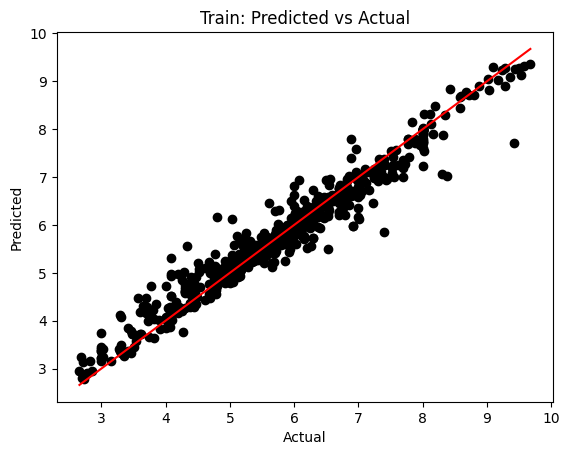

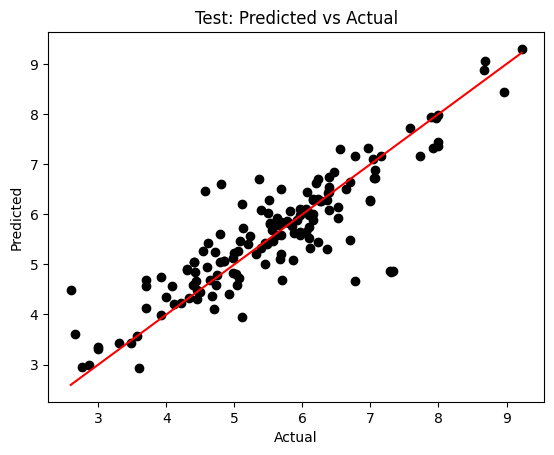

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import math

# Hyperparameter grid without 'auto'
hyper_params_rdf = {
    'n_estimators': np.arange(1, 400, 1),
    'max_features': ['sqrt', 'log2', None],  # Remove 'auto'
    'n_estimators': np.arange(1, 400, 10),
    'max_depth': np.arange(1, 30, 5),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],}


# Define and fit the model
np.random.seed(22)
RF = RandomForestRegressor(random_state=42)
g_search_RF = RandomizedSearchCV(RF, hyper_params_rdf, cv=10, n_jobs=-1)
rf_model = g_search_RF.fit(X_Train, Y_Train)

# Make predictions
predict_rf_train = g_search_RF.predict(X_Train)
predict_rf_test = g_search_RF.predict(X_Test)

# Calculate and print metrics
mse_rf_train = mean_squared_error(Y_Train, predict_rf_train)
mse_rf_test = mean_squared_error(Y_Test, predict_rf_test)
print(f"Train RMSE: {math.sqrt(mse_rf_train)}")
print(f"Test RMSE: {math.sqrt(mse_rf_test)}")

r2_rf_train = r2_score(Y_Train, predict_rf_train)
r2_rf_test = r2_score(Y_Test, predict_rf_test)
print(f"Train R²: {r2_rf_train}")
print(f"Test R²: {r2_rf_test}")

# Best estimator
print("Best estimator:", g_search_RF.best_estimator_)

# Plot scatter for training data
plt.scatter(Y_Train, predict_rf_train, marker='o', alpha=1, color="black")
plt.plot([min(Y_Train), max(Y_Train)], [min(Y_Train), max(Y_Train)], color="red")
plt.title("Train: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Plot scatter for test data
plt.scatter(Y_Test, predict_rf_test, marker='o', alpha=1, color="black")
plt.plot([min(Y_Test), max(Y_Test)], [min(Y_Test), max(Y_Test)], color="red")
plt.title("Test: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


Train RMSE: 0.8035986897919686
Test RMSE: 0.7901037177458184
Train R²: 0.6685134460899385
Test R²: 0.6245916813006096
Best estimator: RandomForestRegressor(max_depth=13, max_features='sqrt', min_samples_leaf=10,
                      min_samples_split=15, n_estimators=175, random_state=42)


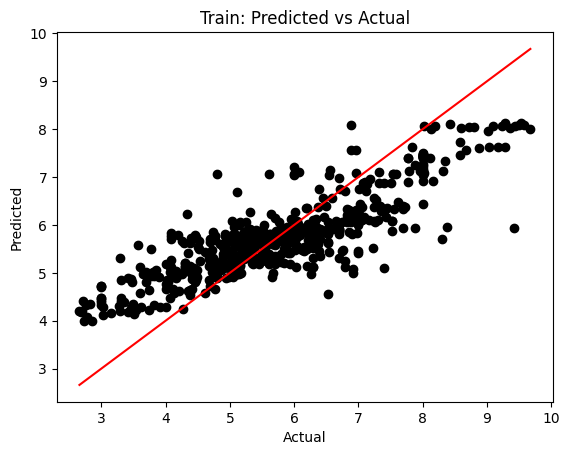

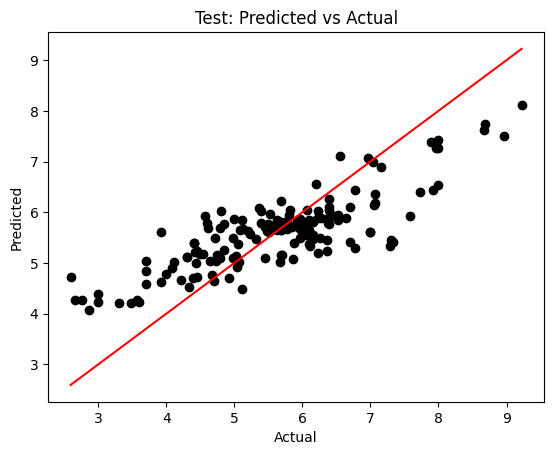

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import math

# Sample data (Replace X and Y with your dataset)
# X, Y = ...
# X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Updated Hyperparameter grid
hyper_params_rdf = {
    'n_estimators': np.arange(50, 200, 25),
    'max_features': ['sqrt', 'log2'],
    'max_depth': np.arange(5, 20, 2),
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [3, 5, 10],
}

# Define and fit the model
np.random.seed(42)
RF = RandomForestRegressor(random_state=42)
g_search_RF = RandomizedSearchCV(
    RF, hyper_params_rdf, cv=5, n_jobs=-1, scoring='neg_mean_squared_error', random_state=42
)
rf_model = g_search_RF.fit(X_Train, Y_Train)

# Make predictions
predict_rf_train = g_search_RF.predict(X_Train)
predict_rf_test = g_search_RF.predict(X_Test)

# Calculate and print metrics
mse_rf_train = mean_squared_error(Y_Train, predict_rf_train)
mse_rf_test = mean_squared_error(Y_Test, predict_rf_test)
print(f"Train RMSE: {math.sqrt(mse_rf_train)}")
print(f"Test RMSE: {math.sqrt(mse_rf_test)}")

r2_rf_train = r2_score(Y_Train, predict_rf_train)
r2_rf_test = r2_score(Y_Test, predict_rf_test)
print(f"Train R²: {r2_rf_train}")
print(f"Test R²: {r2_rf_test}")

# Best estimator
print("Best estimator:", g_search_RF.best_estimator_)

# Plot scatter for training data
plt.scatter(Y_Train, predict_rf_train, marker='o', alpha=1, color="black")
plt.plot([min(Y_Train), max(Y_Train)], [min(Y_Train), max(Y_Train)], color="red")
plt.title("Train: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Plot scatter for test data
plt.scatter(Y_Test, predict_rf_test, marker='o', alpha=1, color="black")
plt.plot([min(Y_Test), max(Y_Test)], [min(Y_Test), max(Y_Test)], color="red")
plt.title("Test: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


Train RMSE: 0.2648704292336009
Test RMSE: 0.6539612775569587
Train R²: 0.9639874041255171
Test R²: 0.7428184861005944
Best estimator: RandomForestRegressor(max_depth=19, max_features=None, n_estimators=300,
                      random_state=42)


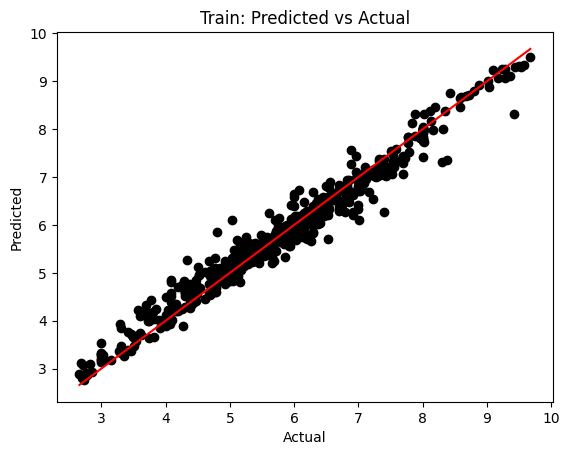

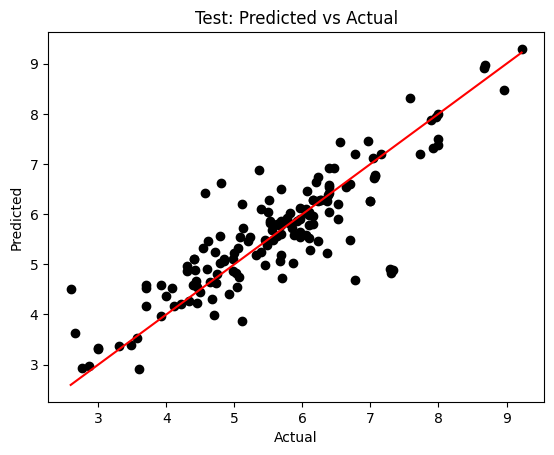

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import math

# Sample data (Replace X and Y with your dataset)
# X, Y = ...
# X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Updated Hyperparameter grid with wider ranges
hyper_params_rdf = {
    'n_estimators': np.arange(100, 500, 50),  # Increase number of estimators
    'max_features': ['sqrt', 'log2', None],  # Consider no feature restriction
    'max_depth': np.arange(5, 30, 2),  # Expand range of max_depth
    'min_samples_split': [2, 5, 10, 20],  # More options for min_samples_split
    'min_samples_leaf': [1, 3, 5, 10],  # More options for min_samples_leaf
}

# Define and fit the model
np.random.seed(42)
RF = RandomForestRegressor(random_state=42)
g_search_RF = RandomizedSearchCV(
    RF, hyper_params_rdf, cv=5, n_jobs=-1, scoring='neg_mean_squared_error', random_state=42, n_iter=100
)
rf_model = g_search_RF.fit(X_Train, Y_Train)

# Make predictions
predict_rf_train = g_search_RF.predict(X_Train)
predict_rf_test = g_search_RF.predict(X_Test)

# Calculate and print metrics
mse_rf_train = mean_squared_error(Y_Train, predict_rf_train)
mse_rf_test = mean_squared_error(Y_Test, predict_rf_test)
print(f"Train RMSE: {math.sqrt(mse_rf_train)}")
print(f"Test RMSE: {math.sqrt(mse_rf_test)}")

r2_rf_train = r2_score(Y_Train, predict_rf_train)
r2_rf_test = r2_score(Y_Test, predict_rf_test)
print(f"Train R²: {r2_rf_train}")
print(f"Test R²: {r2_rf_test}")

# Best estimator
print("Best estimator:", g_search_RF.best_estimator_)

# Plot scatter for training data
plt.scatter(Y_Train, predict_rf_train, marker='o', alpha=1, color="black")
plt.plot([min(Y_Train), max(Y_Train)], [min(Y_Train), max(Y_Train)], color="red")
plt.title("Train: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Plot scatter for test data
plt.scatter(Y_Test, predict_rf_test, marker='o', alpha=1, color="black")
plt.plot([min(Y_Test), max(Y_Test)], [min(Y_Test), max(Y_Test)], color="red")
plt.title("Test: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()
